In [1]:
import pandas as pd
import numpy as np

In [2]:
from datetime import datetime, timedelta


np.random.seed(0)


def generate_date_times(n):
    start_date = datetime.now() - timedelta(days=365 * 10)
    return [start_date + timedelta(days=np.random.randint(0, 365 * 10), 
                                   hours=np.random.randint(0, 24), 
                                   minutes=np.random.randint(0, 60)) for _ in range(n)]


n_sightings = 1000

date_times = generate_date_times(n_sightings)
latitudes = np.random.uniform(-90, 90, n_sightings)
longitudes = np.random.uniform(-180, 180, n_sightings)
ufo_seen = np.random.choice([0, 1], n_sightings, p=[0.7, 0.3])

ufo_data = pd.DataFrame({
    'Date_Time': date_times,
    'Latitude': latitudes,
    'Longitude': longitudes,
    'UFO_Seen': ufo_seen
})

ufo_data

,Date_Time,Latitude,Longitude,UFO_Seen
0,2022-05-21 10:16:30.126230,-36.111788,-71.197894,0
1,2023-11-03 22:22:30.126230,-17.911444,76.394993,0
2,2019-08-24 01:32:30.126230,-13.733768,-143.015652,1
3,2015-08-31 12:59:30.126230,9.411732,-72.300062,1
4,2022-02-25 00:47:30.126230,-20.991347,19.067517,0
...,...,...,...,...
995,2016-10-27 07:00:30.126230,17.439805,126.251465,0
996,2023-08-13 06:07:30.126230,74.280712,164.535541,0
997,2020-06-13 11:47:30.126230,-65.680182,-85.491322,0
998,2022-04-22 16:55:30.126230,-44.866471,64.635096,0


In [3]:
ufo_data.shape

(1000, 4)

In [4]:
ufo_data.describe()

,Date_Time,Latitude,Longitude,UFO_Seen
count,1000,1000.000000,1000.000000,1000.000000
mean,2019-10-29 11:27:34.326230016,2.034816,1.433071,0.300000
min,2014-11-27 03:14:30.126230,-89.966391,-179.671349,0.000000
25%,2017-05-27 02:19:45.126230016,-43.781102,-88.959884,0.000000
50%,2019-10-03 05:44:00.126230016,1.671404,1.794693,0.000000
75%,2022-04-19 09:03:00.126230016,48.016479,95.319097,1.000000
max,2024-11-21 11:05:30.126230,89.857440,179.793516,1.000000
std,NaN,52.164692,104.966940,0.458487


In [5]:
ufo_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date_Time  1000 non-null   datetime64[ns]
 1   Latitude   1000 non-null   float64       
 2   Longitude  1000 non-null   float64       
 3   UFO_Seen   1000 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 31.4 KB


In [6]:
import datetime

In [7]:
ufo_data['Date'] = ufo_data['Date_Time'].dt.date
ufo_data['Time'] = ufo_data['Date_Time'].dt.time

In [8]:
ufo_data.head(2)

,Date_Time,Latitude,Longitude,UFO_Seen,Date,Time
0,2022-05-21 10:16:30.126230,-36.111788,-71.197894,0,2022-05-21,10:16:30.126230
1,2023-11-03 22:22:30.126230,-17.911444,76.394993,0,2023-11-03,22:22:30.126230


In [9]:
ufo_data.drop(columns=['Date_Time'],inplace = True)

In [10]:
ufo_data.head(2)

,Latitude,Longitude,UFO_Seen,Date,Time
0,-36.111788,-71.197894,0,2022-05-21,10:16:30.126230
1,-17.911444,76.394993,0,2023-11-03,22:22:30.126230


In [11]:
ufo_data.dtypes

Latitude     float64
Longitude    float64
UFO_Seen       int64
Date          object
Time          object
dtype: object

In [13]:
ufo_data['Tis'] = ufo_data['Time'].apply(lambda x : x.hour * 3600 + x.minute * 60 + x.second)

In [14]:
ufo_data.head(2)

,Latitude,Longitude,UFO_Seen,Date,Time,Tis
0,-36.111788,-71.197894,0,2022-05-21,10:16:30.126230,36990
1,-17.911444,76.394993,0,2023-11-03,22:22:30.126230,80550


In [15]:
ufo_data.dtypes

Latitude     float64
Longitude    float64
UFO_Seen       int64
Date          object
Time          object
Tis            int64
dtype: object

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
ufo_data['Date'] = pd.to_datetime(ufo_data['Date'])

In [19]:
ufo_data['Month'] = ufo_data['Date'].dt.month
ufo_data['Day'] = ufo_data['Date'].dt.day
ufo_data['Year'] = ufo_data['Date'].dt.year

In [20]:
monthly_trends = ufo_data.groupby('Month').size()
yearly_trends = ufo_data.groupby('Year').size()


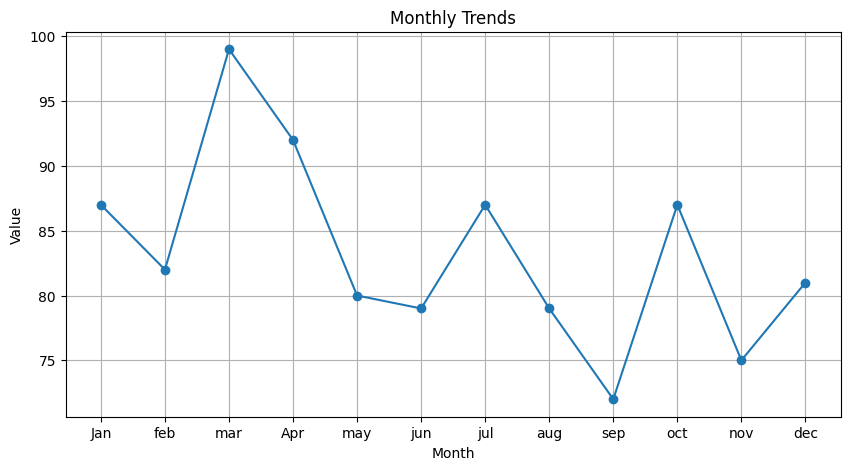

In [24]:
plt.figure(figsize=(10,5))
plt.plot(monthly_trends.index,monthly_trends.values,marker = 'o')
plt.xticks(range(1,13),['Jan','feb','mar','Apr','may','jun','jul','aug','sep','oct','nov','dec'])
plt.title('Monthly Trends')
plt.xlabel('Month')
plt.ylabel('Value')
plt.grid()
plt.show()


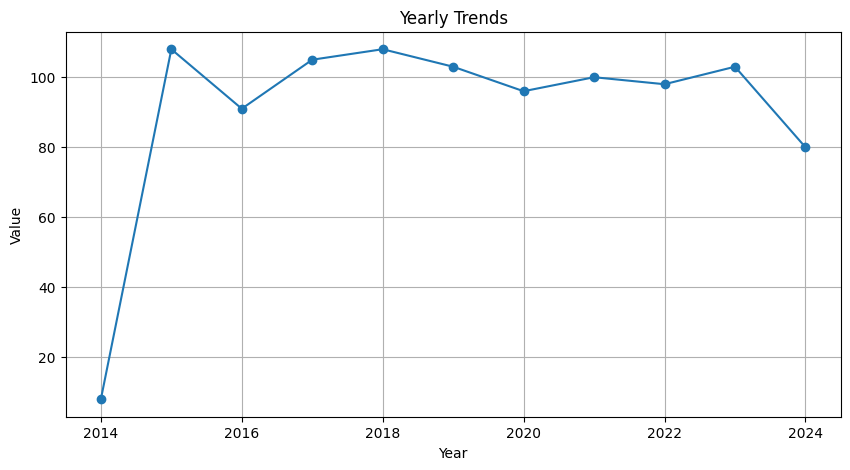

In [26]:
plt.figure(figsize=(10,5))
plt.plot(yearly_trends.index,yearly_trends.values,marker='o')
plt.title('Yearly Trends')
plt.xlabel('Year')
plt.ylabel('Value')
plt.grid()
plt.show()

In [27]:
weekly_trends = ufo_data.groupby('Day').size()

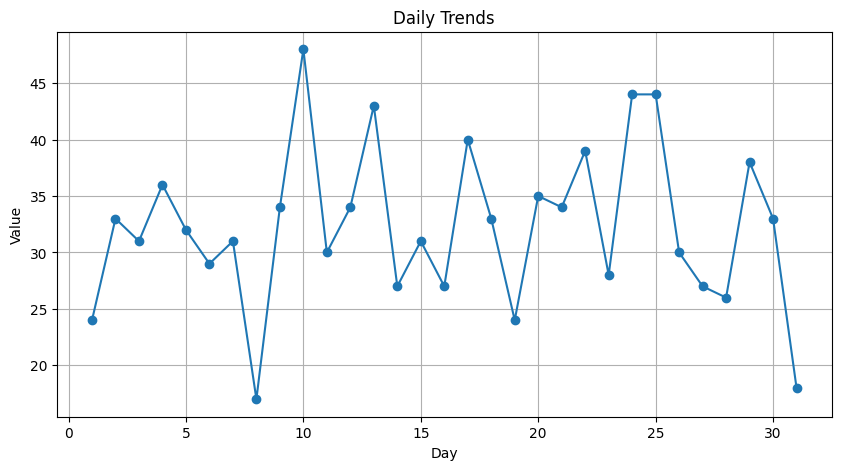

In [30]:
plt.figure(figsize=(10,5))
plt.plot(weekly_trends.index,weekly_trends.values,marker='o')
plt.title('Daily Trends')
plt.xlabel('Day')
plt.ylabel('Value')
plt.grid()
plt.show()

In [37]:
ufo_data['Weekday'] = ufo_data['Date'].dt.weekday
weekly11_trends = ufo_data.groupby('Weekday').size()

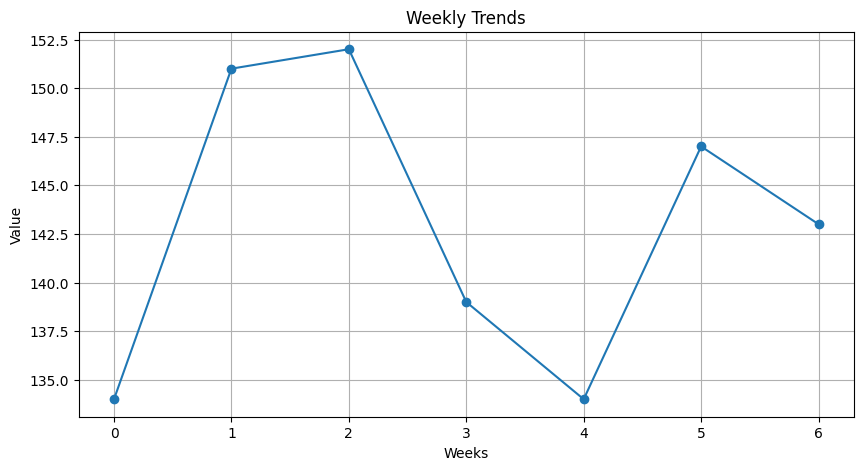

In [38]:
plt.figure(figsize=(10,5))
plt.plot(weekly11_trends.index,weekly11_trends.values,marker='o')
plt.title('Weekly Trends')
plt.xlabel('Weeks')
plt.ylabel('Value')
plt.grid()
plt.show()

In [32]:
from statsmodels.tsa.stattools import adfuller

In [33]:
from sklearn.preprocessing import StandardScaler

In [34]:
ufo_data.head(2)

,Latitude,Longitude,UFO_Seen,Date,Time,Tis,Month,Day,Year
0,-36.111788,-71.197894,0,2022-05-21,10:16:30.126230,36990,5,21,2022
1,-17.911444,76.394993,0,2023-11-03,22:22:30.126230,80550,11,3,2023


In [35]:
scaler = StandardScaler()
ufo_data[['Latitude','Longitude']] = scaler.fit_transform(ufo_data[['Latitude','Longitude']])

In [36]:
ufo_data.head(2)

,Latitude,Longitude,UFO_Seen,Date,Time,Tis,Month,Day,Year
0,-0.731638,-0.692288,0,2022-05-21,10:16:30.126230,36990,5,21,2022
1,-0.382562,0.714505,0,2023-11-03,22:22:30.126230,80550,11,3,2023


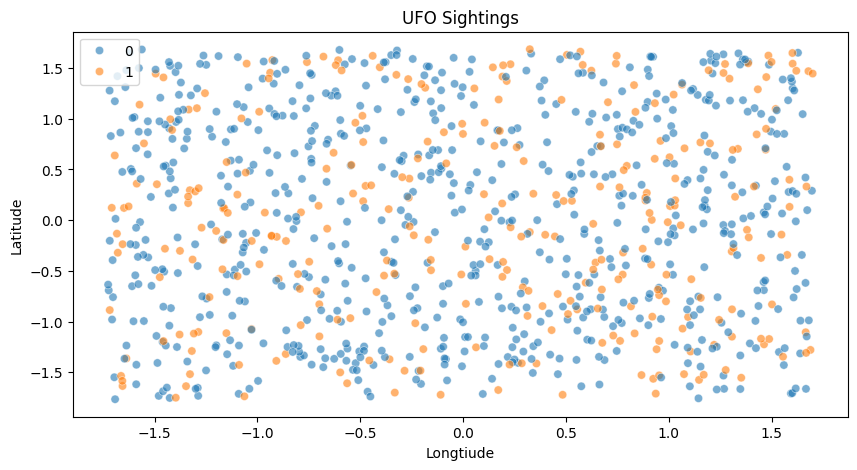

In [42]:
plt.figure(figsize=(10,5))
sns.scatterplot(x = ufo_data['Longitude'],y = ufo_data['Latitude'],hue = ufo_data['UFO_Seen'],alpha=0.6)
plt.title('UFO Sightings')
plt.xlabel('Longtiude')
plt.ylabel('Latitude')
plt.legend()
plt.show()


In [45]:
ufo_data.drop(columns = ['Date','Time'],inplace=True)

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [52]:
from sklearn.linear_model import LogisticRegression

In [48]:
from sklearn.metrics import accuracy_score

In [49]:
X = ufo_data.drop(columns = ['UFO_Seen'])
y = ufo_data['UFO_Seen']

In [47]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

Model: LogisticRegression
Accuracy: 0.72
Model: DecisionTreeClassifier
Accuracy: 0.56
Model: RandomForestClassifier
Accuracy: 0.705


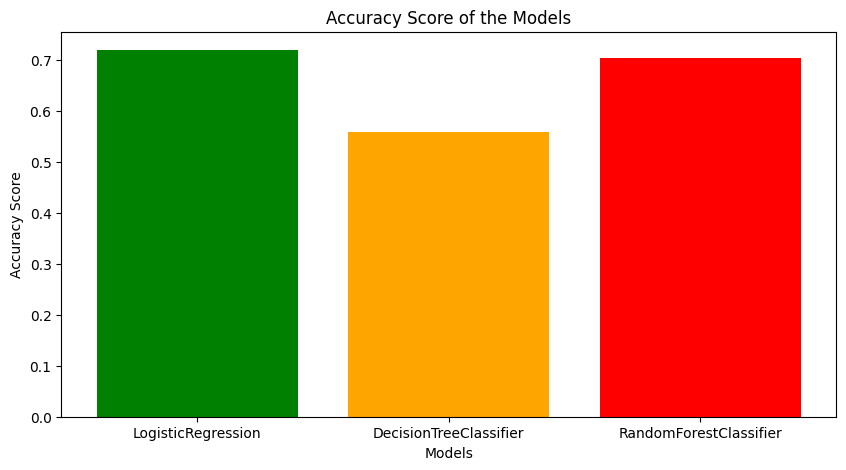

In [ ]:
models = [LogisticRegression, DecisionTreeClassifier, RandomForestClassifier]
model_names = []
accuracies = []


for model in models:
    model_instance = model()  
    model_instance.fit(X_train, y_train) 
    y_pred = model_instance.predict(X_test)  
    
    
    model_names.append(model.__name__) 
    acc = accuracy_score(y_test, y_pred)  
    accuracies.append(acc)  
    
    print(f"Model: {model.__name__}")
    print(f"Accuracy: {acc}")


plt.figure(figsize=(10, 5))
plt.bar(model_names, accuracies, color=['green', 'orange', 'red'])
plt.xlabel('Models')
plt.ylabel('Accuracy Score')
plt.title('Accuracy Score of the Models')
plt.show()
    

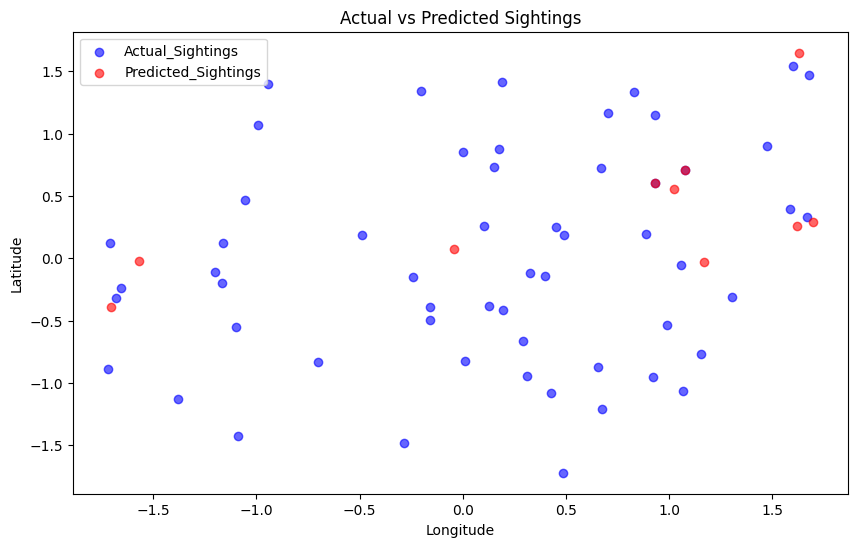

In [68]:
for model in models:
    model_instance = model()
    model_instance.fit(X_train,y_train)
    y_predx = model_instance.predict(X_test)
    actual_sightings  = X_test[y_test==1]
    predicted_sightings = X_test[y_predx == 1] 


plt.figure(figsize=(10,6))
plt.scatter(actual_sightings['Longitude'],actual_sightings['Latitude'],color = 'blue',label='Actual_Sightings',alpha=0.6)
plt.scatter(predicted_sightings['Longitude'],predicted_sightings['Latitude'],color = 'red',label = 'Predicted_Sightings',alpha=0.6)
plt.title('Actual vs Predicted Sightings')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()

In [75]:
ufo_data.head(2)

,Latitude,Longitude,UFO_Seen,Tis,Month,Day,Year,Weekday
0,-0.731638,-0.692288,0,36990,5,21,2022,5
1,-0.382562,0.714505,0,80550,11,3,2023,4


In [86]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [81]:
time = ufo_data.groupby('Year')['UFO_Seen'].sum()


In [82]:
time = time.sort_index()

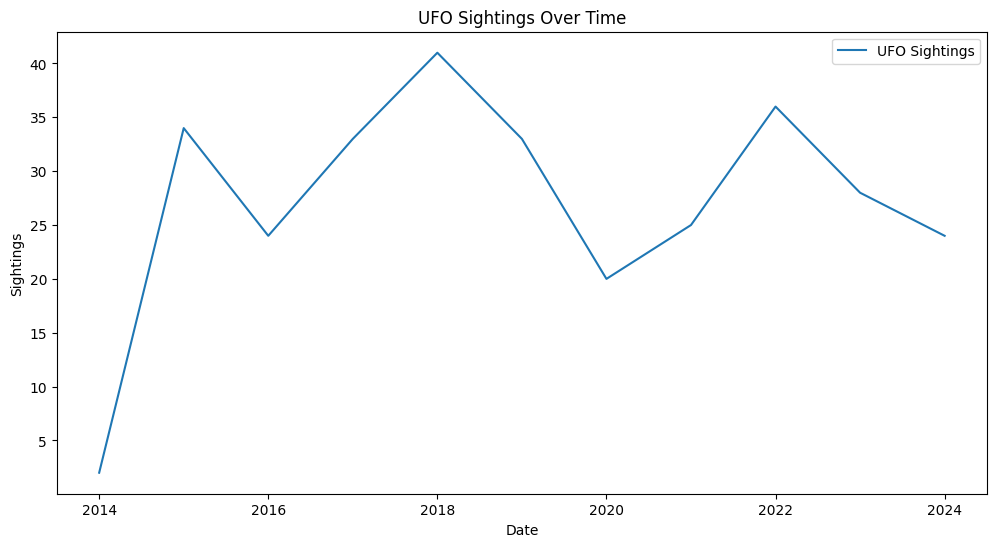

In [83]:
plt.figure(figsize=(12, 6))
plt.plot(time, label='UFO Sightings')
plt.title('UFO Sightings Over Time')
plt.xlabel('Date')
plt.ylabel('Sightings')
plt.legend()
plt.show()

                               SARIMAX Results                                
Dep. Variable:               UFO_Seen   No. Observations:                   11
Model:                 ARIMA(2, 1, 2)   Log Likelihood            -5086737.230
Date:                Sat, 23 Nov 2024   AIC                       10173484.461
Time:                        22:13:45   BIC                       10173485.974
Sample:                             0   HQIC                      10173482.801
                                 - 11                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.0381   2.49e-06  -4.17e+05      0.000      -1.038      -1.038
ar.L2         -0.4454    1.2e-06  -3.72e+05      0.000      -0.445      -0.445
ma.L1       2.577e-07   2.36e-06      0.109      0.9

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction result

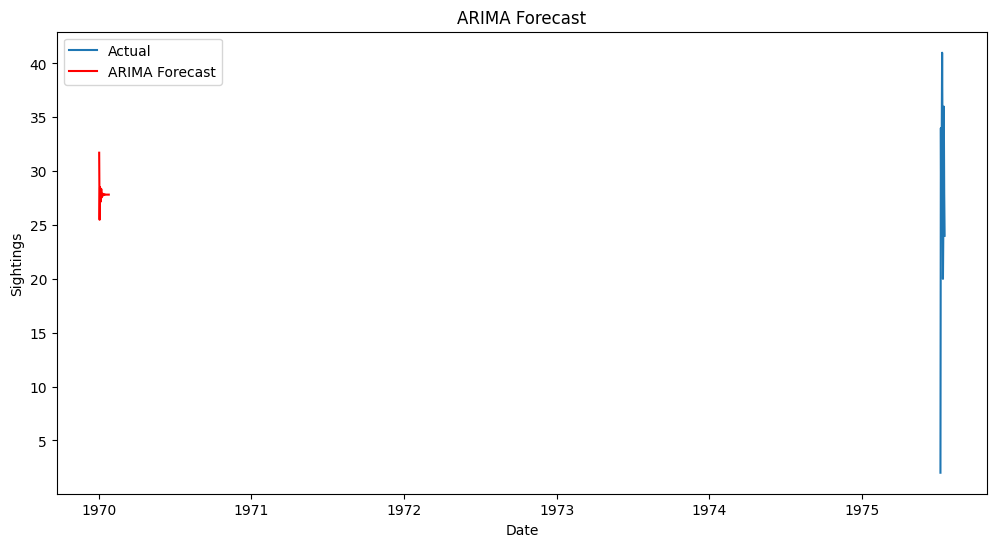

In [88]:
arima_model = ARIMA(time,order=(2,1,2))
arima_model_fit = arima_model.fit()
print(arima_model_fit.summary())

steps = 24
forecast_arima = arima_model_fit.forecast(steps=steps)

plt.figure(figsize=(12, 6))
plt.plot(time, label='Actual')
forecast_index = pd.date_range(time.index[-1], periods=steps + 1, freq='D')[1:]  # Adjust 'D' for frequency
plt.plot(forecast_index, forecast_arima, label='ARIMA Forecast', color='red')
plt.title('ARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('Sightings')
plt.legend()
plt.show()